# [LAB 07] 5. 독립표본 T-Test
## #연습문제

In [3]:
from hossam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame, pivot_table

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


#### 문제 1 - 상표에 따라 주성분 A의 함량에 어떤 차이가 있는가?

In [4]:
df1 = load_data('material')
df1.head()

📚 어떤 화학 약품에 사용되는 서로 다른 상표의 주성분 A 함량표 (출처: 방송통신대학교 통계학개론)


,상표1,상표2
0,80.400,81.800
1,78.200,82.700
2,80.100,80.700
3,77.100,84.000
4,79.600,79.000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상표1 vs. 상표2: t-test independent samples, P_val:1.421e-01 t=-1.528e+00


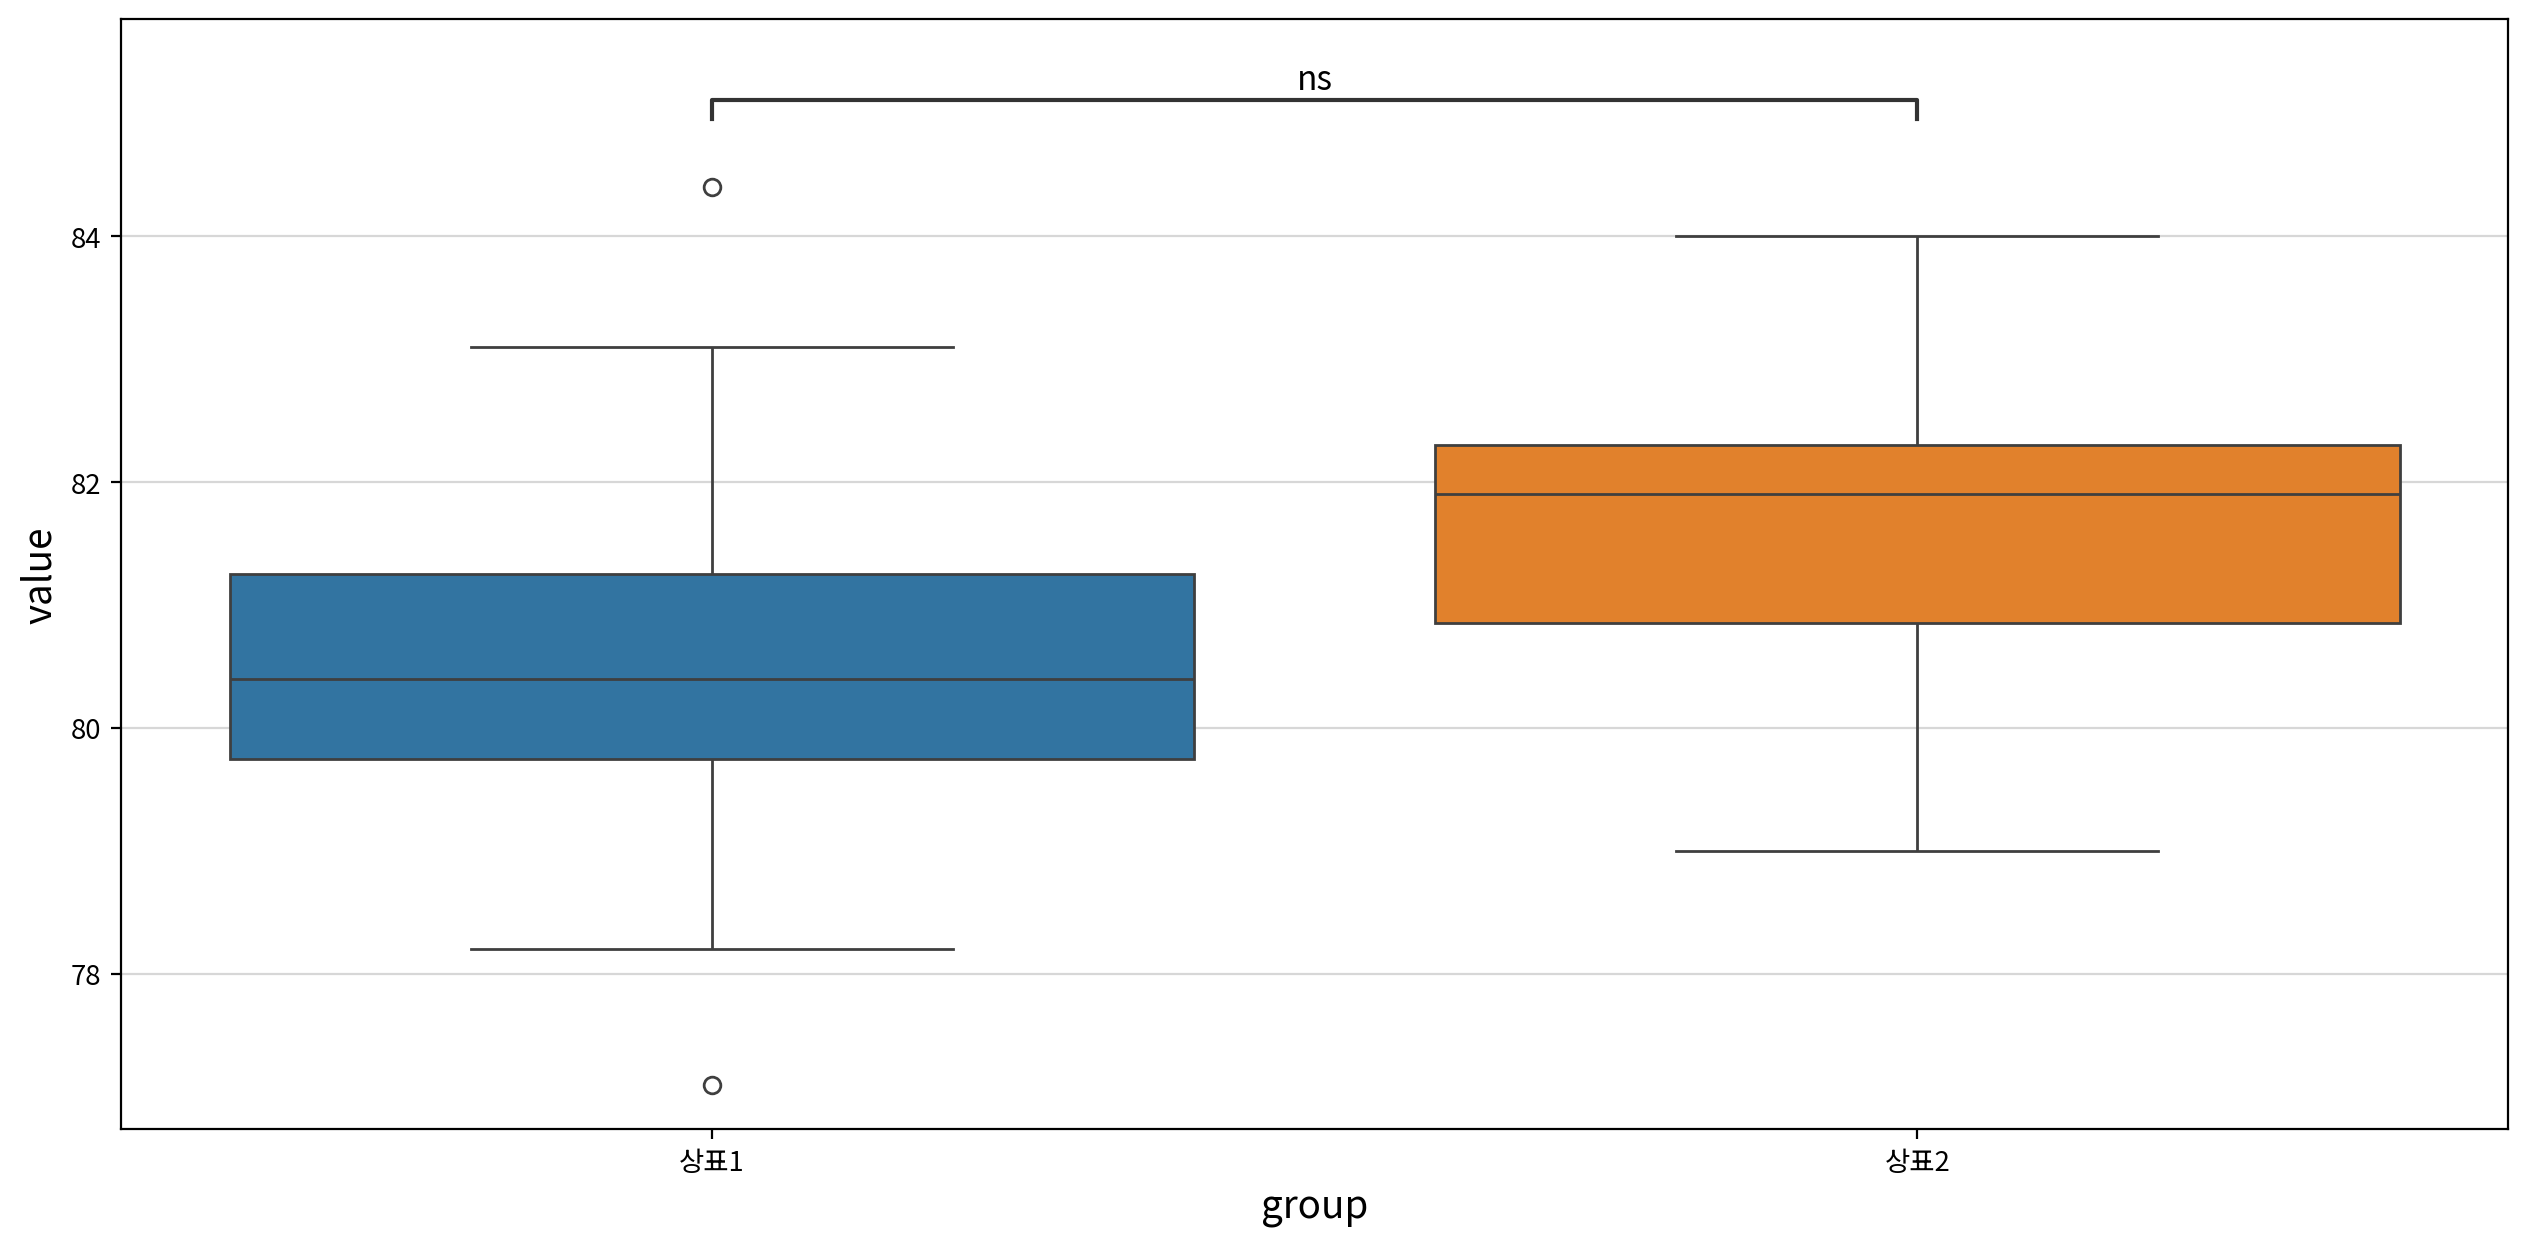

statistic  p-value  significant     result
test           alternative                                            
Student t-test two-sided       -1.528    0.142        False  상표1 = 상표2
               less            -1.528    0.071        False  상표1 ≥ 상표2
               greater         -1.528    0.929        False  상표1 ≤ 상표2

In [5]:
my_stats.test_independent(df1, '상표1', '상표2')

- 상표 1과 상표 2에 대해 양측 검정을 한 결과 p-value가 0.142로 주성분 A 함량은 통계적으로 차이가 없다.(p>0.05)

#### 문제 2- 남성과 여성의 평균키에 어떤 차이가 있는가?

In [6]:
df2 = load_data('adult_height')
df2.head()

📚 성인 30명의 성별(sex), 신장(height) 데이터 (출처: 방송통신대학교 바이오통계학)


,sex,height
0,F,161
1,F,160
2,F,164
3,F,172
4,F,157


In [7]:
df2_group = df2.copy()
df2_group['idx']=df2_group.groupby("sex").cumcount()
df2_group

,sex,height,idx
0,F,161,0
1,F,160,1
2,F,164,2
3,F,172,3
4,F,157,4
5,F,164,5
6,F,166,6
7,F,169,7
8,F,166,8
9,F,164,9


In [8]:
df2_pivot = pivot_table(df2_group, index='idx', columns='sex', values='height')
df2_pivot.head()

sex,F,M
idx,,
0,161.000,166.000
1,160.000,157.000
2,164.000,171.000
3,172.000,174.000
4,157.000,170.000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

F vs. M: t-test independent samples, P_val:4.477e-04 t=-3.976e+00


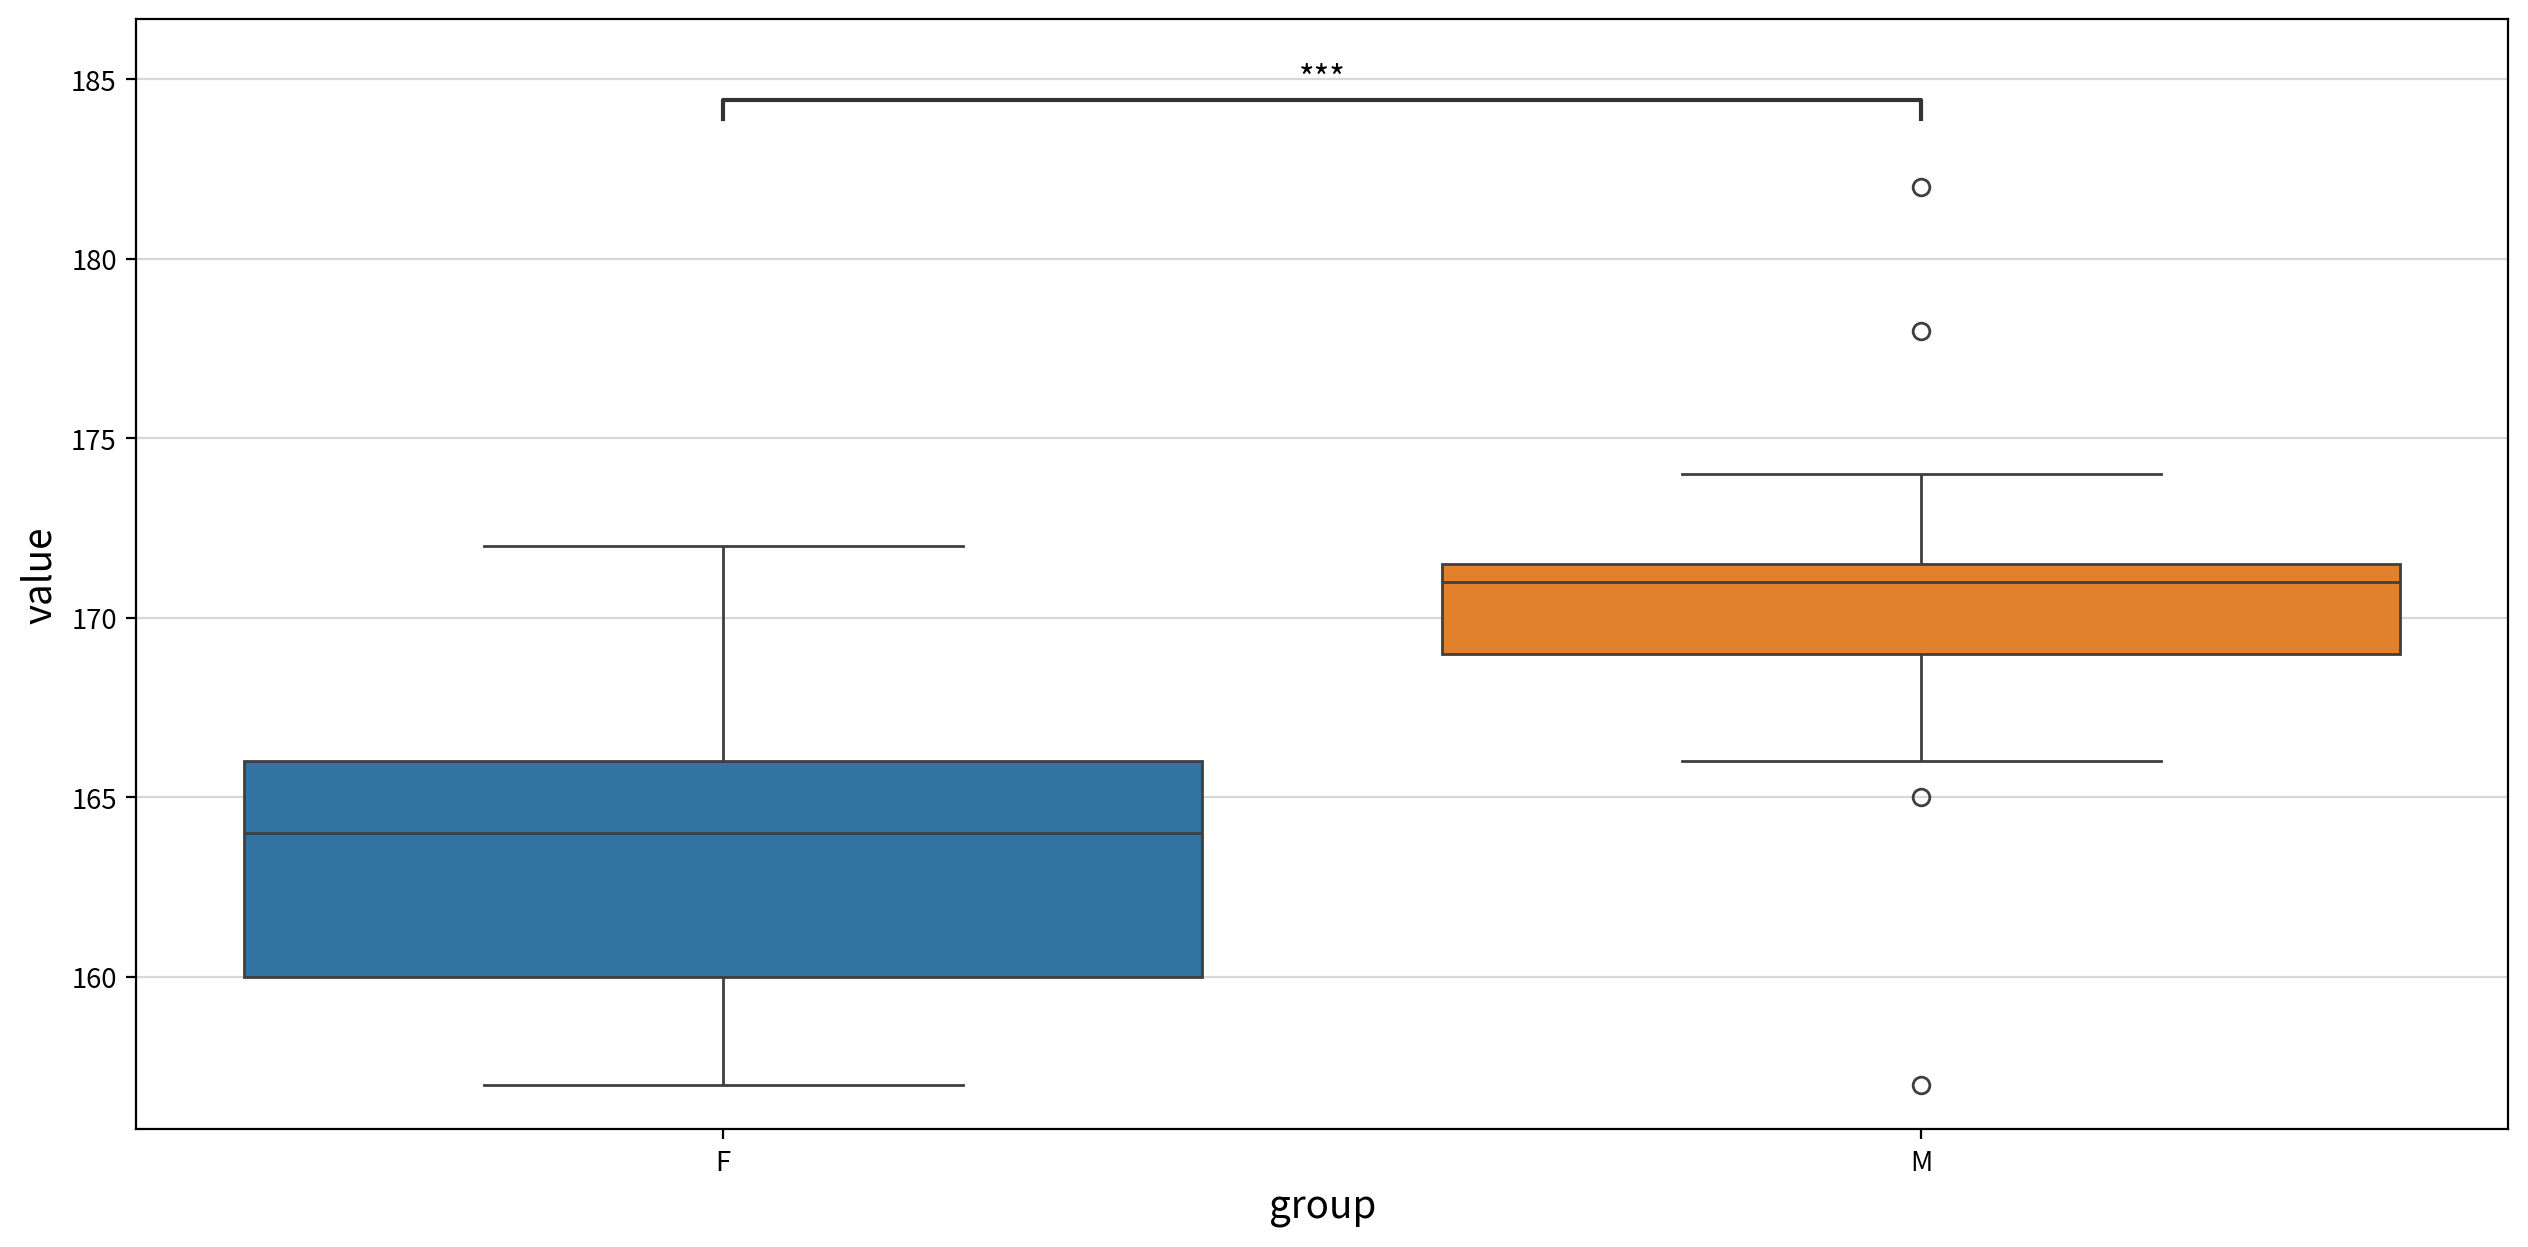

statistic  p-value  significant result
test           alternative                                        
Student t-test two-sided       -3.976    0.000         True  F ≠ M
               less            -3.976    0.000         True  F < M
               greater         -3.976    1.000        False  F ≤ M

In [9]:
my_stats.test_independent(df2_pivot, 'F', 'M')

- 여성과 남성의 평균키에 대해 양측검정을 실시한 결과 p-value는 0.000으로 성별간의 평균키는 통계적으로 유의한 차이가 있다(p<0.05)
- 여성과 남성의 평균키에 대해 좌측 단측검정을 실시간 결과 p-value는 0.000으로 여성의 평균키가 남성의 평균키보다 통계적으로 유의하게 작았다.(p<0.05)
- 여성과 남성의 평균키에 대해 우측 단측검정을 실시한 결과 p-valuesms 1.000으로 여성의 평균키가 남성의 평균키보다 통계적으로 유의하게 크지 않았다(p≥0.05)
즉 여성이 남성보다 작다.